In [3]:
from google.colab import files
uploaded = files.upload()

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
df = pd.read_csv('heart.csv')

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
print("Jumlah baris dan kolom:", df.shape)
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

Jumlah baris dan kolom: (1025, 14)
Jumlah baris: 1025
Jumlah kolom: 14


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


In [ ]:
missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    'Kolom': missing_values.index,
    'Jumlah Missing Value': missing_values.values
})

print("Jumlah Missing Value pada Setiap Kolom:")
display(missing_df)

Jumlah Missing Value pada Setiap Kolom:


,Kolom,Jumlah Missing Value
0,age,0
1,sex,0
2,cp,0
3,trestbps,0
4,chol,0
5,fbs,0
6,restecg,0
7,thalach,0
8,exang,0
9,oldpeak,0


In [ ]:
duplicate_count = df.duplicated().sum()

print("Jumlah data duplikat:", duplicate_count)

Jumlah data duplikat: 723


In [ ]:
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Data duplikat berhasil dihapus.")
else:
    print("Tidak terdapat data duplikat.")

Data duplikat berhasil dihapus.


In [ ]:
print("Ukuran dataset setelah cleaning:", df.shape)

Ukuran dataset setelah cleaning: (302, 14)


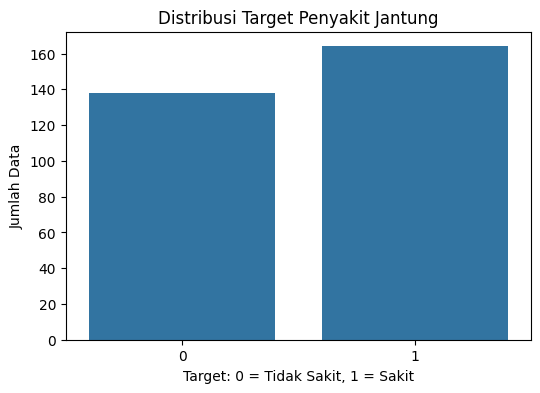

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='target')
plt.title('Distribusi Target Penyakit Jantung')
plt.xlabel('Target: 0 = Tidak Sakit, 1 = Sakit')
plt.ylabel('Jumlah Data')
plt.show()

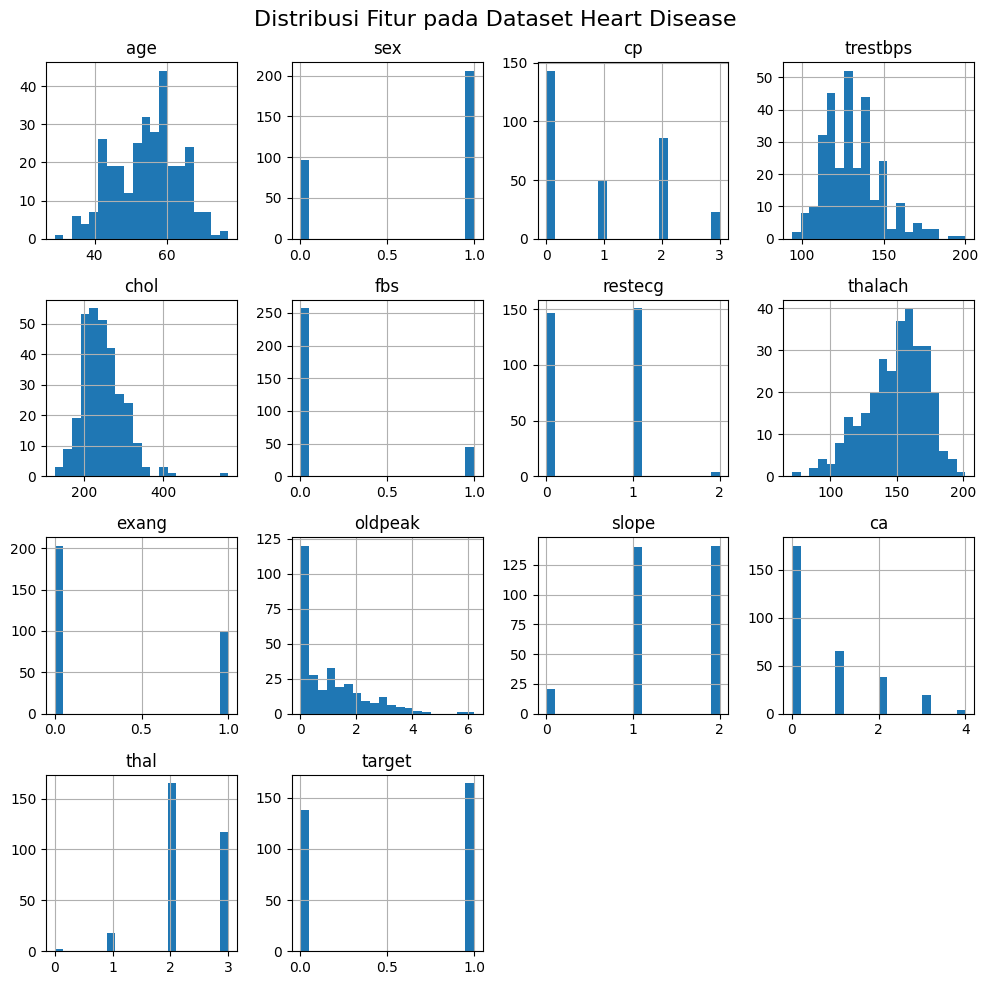

In [ ]:
df.hist(figsize=(10, 10), bins=20)
plt.suptitle('Distribusi Fitur pada Dataset Heart Disease', fontsize=16)
plt.tight_layout()
plt.show()

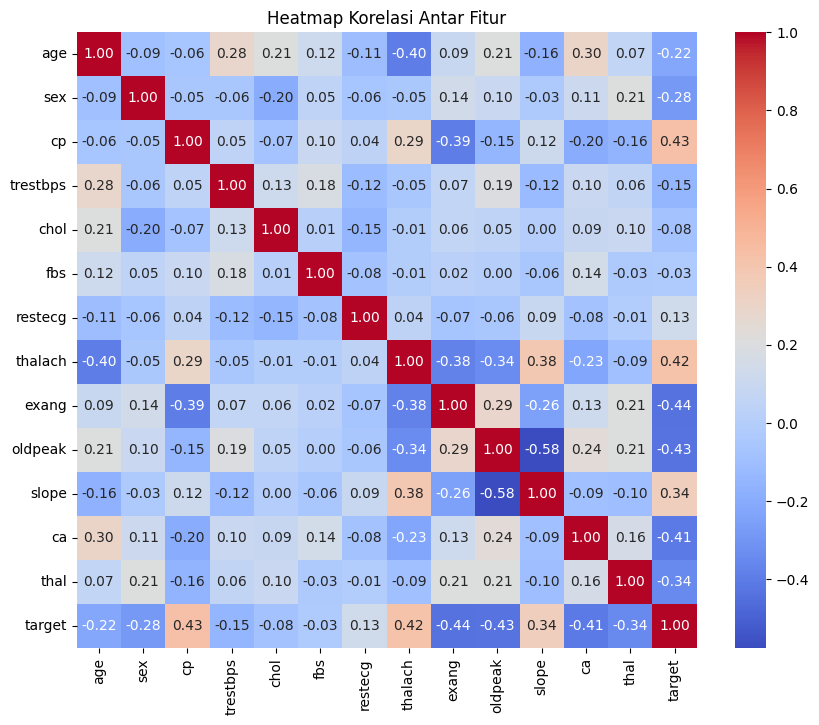

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

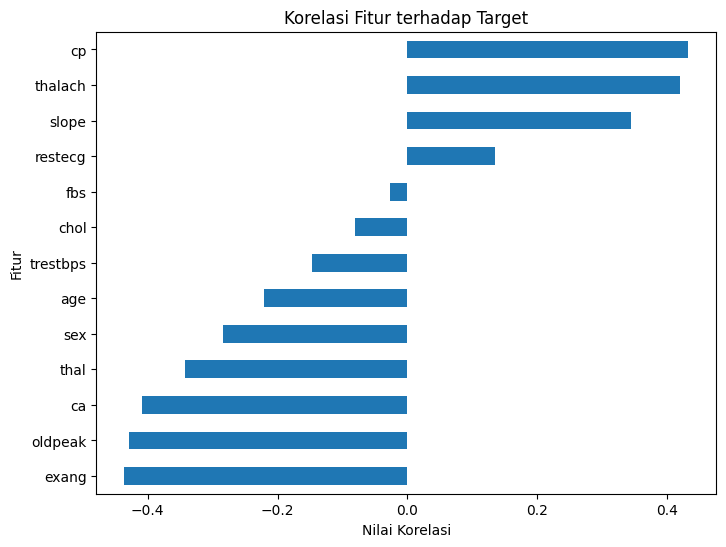

In [ ]:
target_corr = df.corr()['target'].sort_values(ascending=False)

plt.figure(figsize=(8,6))
target_corr.drop('target').sort_values().plot(kind='barh')
plt.title('Korelasi Fitur terhadap Target')
plt.xlabel('Nilai Korelasi')
plt.ylabel('Fitur')
plt.show()

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

print("Ukuran fitur X:", X.shape)
print("Ukuran target y:", y.shape)

Ukuran fitur X: (302, 13)
Ukuran target y: (302,)


In [ ]:
categorical_cols = X.select_dtypes(include=['object']).columns

print("Kolom kategorikal:", list(categorical_cols))

Kolom kategorikal: []


In [ ]:
if len(categorical_cols) > 0:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
    print("Encoding data kategorikal selesai.")
else:
    print("Tidak terdapat kolom kategorikal, encoding tidak diperlukan.")

Tidak terdapat kolom kategorikal, encoding tidak diperlukan.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing:", X_test.shape[0])

Jumlah data training: 241
Jumlah data testing: 61


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [ ]:
print("Hasil prediksi Random Forest:")
print(y_pred_rf)

Hasil prediksi Random Forest:
[0 1 0 1 1 0 1 0 1 0 1 0 1 1 0 1 1 0 1 1 0 0 1 0 1 0 0 0 0 1 0 1 0 1 0 1 0
 1 1 1 1 1 1 1 0 0 1 0 1 1 1 1 1 0 1 1 0 1 0 0 0]


In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Evaluasi Model Random Forest")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1-Score :", f1_rf)

Evaluasi Model Random Forest
Accuracy : 0.7540983606557377
Precision: 0.7647058823529411
Recall   : 0.7878787878787878
F1-Score : 0.7761194029850746


In [ ]:
eval_rf = pd.DataFrame({
    'Model': ['Random Forest'],
    'Accuracy': [accuracy_rf],
    'Precision': [precision_rf],
    'Recall': [recall_rf],
    'F1-Score': [f1_rf]
})

display(eval_rf)

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.754098,0.764706,0.787879,0.776119


In [ ]:
print("Classification Report Random Forest:")
print(classification_report(y_test, y_pred_rf))

Classification Report Random Forest:
              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61



In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix Random Forest:")
print(cm_rf)

Confusion Matrix Random Forest:
[[20  8]
 [ 7 26]]


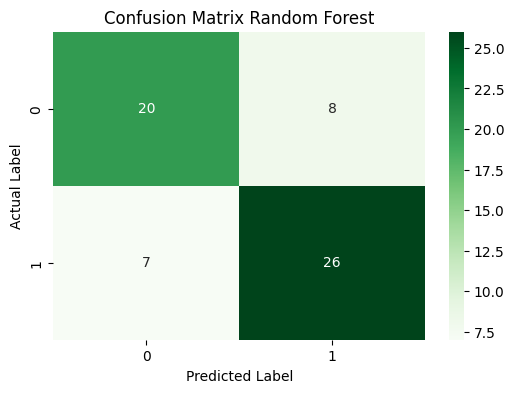

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

display(feature_importance)

,Fitur,Importance
2,cp,0.173969
7,thalach,0.131634
11,ca,0.105700
9,oldpeak,0.096577
12,thal,0.090418
0,age,0.083049
8,exang,0.073679
3,trestbps,0.072088
4,chol,0.067384
1,sex,0.040229


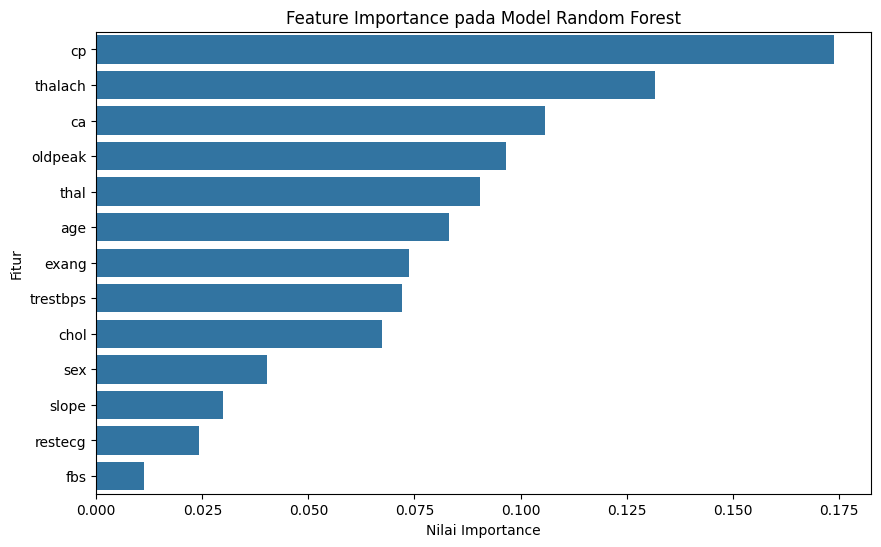

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Fitur'
)

plt.title('Feature Importance pada Model Random Forest')
plt.xlabel('Nilai Importance')
plt.ylabel('Fitur')
plt.show()

In [ ]:
print("Interpretasi:")
print("Model Random Forest digunakan untuk memprediksi penyakit jantung berdasarkan fitur medis pasien.")
print("Evaluasi dilakukan menggunakan accuracy, precision, recall, dan F1-score.")
print("Confusion matrix digunakan untuk melihat jumlah prediksi benar dan salah.")
print("Feature importance digunakan untuk mengetahui fitur yang paling berpengaruh terhadap hasil prediksi model.")

Interpretasi:
Model Random Forest digunakan untuk memprediksi penyakit jantung berdasarkan fitur medis pasien.
Evaluasi dilakukan menggunakan accuracy, precision, recall, dan F1-score.
Confusion matrix digunakan untuk melihat jumlah prediksi benar dan salah.
Feature importance digunakan untuk mengetahui fitur yang paling berpengaruh terhadap hasil prediksi model.
